# Data processing: factors {#sec-factors}

This notebook mines and processes the factor data needed. Read the [README.md](README.md)/[@sec-intro] for context about the project.

## Data and methodology

### Raw data

**Sources:** Fama-French 6 factors from [sakethaleti.com/data](https://www.sakethaleti.com/data), or [this Google Drive link](https://drive.google.com/file/d/1TJqtc-8KlwTmtS6V1rGn8xCj2I0mUdo_). Documentation can be found in the section 1 of the [online appendix](https://drive.google.com/file/d/1vN5jPnuwlZhwb3NZGGHdkMYSePk5Sp45/view).

**Format:** Already at the 1-minute level. One column for the minute, and one for each factor. The factors are in returns (not log).

**Filters:**

- Sample period (same as stocks):
    - Range: 2001-01-02 to 2017-12-29. Stocks that are listed or delisted during this period are included.
    - Hours: regular trading hours (09:30 - 16:00 ET).
    - Days: regular trading days, removing days with market-wide halts and diminished trading hours.

**Qualities:**

- The data should be order by `datetime`.
- There shouldn't be data for non-trading days, and there should be all 390 minutes of a day with data.
- The minutes should be left labelled as `9:30 - 9:30:00 -> 9:30:59`, `9:31 - 9:31:00 -> 9:31:59`, ..., `15:59 - 15:59:00 -> 15:59:59`, and no additional `16:00` data point.

All are guaranteed by the source, and checked informally. The last is not, and we might need to transform it.


### Methodology

The steps to process the data are as below.

- Download the data into `data/ff6_1min_returns_raw.csv`. Alternatively, could be read directly from Google Drive.
- Apply the filters above.
- Check if the minutes are labelled correctly, and transform if needed.
- Transform data into log-returns.
- Aggregate the data into left labeled 5-minute blocks (09:30, 09:35, ..., 15:55), by summing the returns of the label minute and the 4 minutes before it. Save it into `data/ff6_5min_returns.csv`.

## Code setup

Codes for debugging:

In [91]:
%reset -f
import importlib

Core modules:

In [ ]:
#| output: false
import os
if os.path.basename(os.getcwd()) == "src": os.chdir("..")

import polars as pl
import numpy as np

import src.utils as ut
import src.graphs as plot
from src.parameters import PARAMETERS as PARS
importlib.reload(ut)
importlib.reload(plot)

## Importing and dates handling

Importing and formatting dates as datetime. A first look at the data is below. The names of the factors are:

- `ff__mkt`: market factor (MKT)
- `ff__smb`: size factor (SMB)
- `ff__hml`: value factor (HML)
- `ff__rmw`: profitability factor (RMW)
- `ff__cma`: investment factor (CMA)
- `ff__umd`: momentum factor (UMD)

In [93]:
data_raw = (
    pl.read_csv("data/factors_1min_returns_raw.csv")
    .with_columns(
        pl.col("datetime")
        .str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S")
    )
)
cols_fct = ["ff__mkt", "ff__smb", "ff__hml", "ff__rmw", "ff__cma", "ff__umd"]

print(f"Data shape: {data_raw.shape}")
print("First rows:")
data_raw.head(3)

Data shape: (2454420, 7)
First rows:


datetime,ff__mkt,ff__smb,ff__hml,ff__rmw,ff__cma,ff__umd
datetime[μs],f64,f64,f64,f64,f64,f64
1996-01-02 09:30:00,-0.002509,0.001133,-0.000592,-0.000541,-0.000922,-0.003535
1996-01-02 09:31:00,-0.000061,0.000184,0.000053,0.00002,-0.000021,0.000204
1996-01-02 09:32:00,-0.000123,0.000121,-0.000045,0.000123,-0.000098,-0.000083


Checking sorting:

In [94]:
if not data_raw["datetime"].is_sorted():
    raise ValueError("Data is not sorted by datetime.")

Filtering by date limits:

In [95]:
data_filt = data_raw.filter(
    (pl.col("datetime").dt.date() >= PARS.date_start.item())
    & (pl.col("datetime").dt.date() <= PARS.date_end.item())
)

All trading days from the NYSE calendar must be present, and all days in the data must be trading days:

In [96]:
dates_trading_all_exist = np.isin(
    PARS.trading_days,
    data_filt["datetime"].dt.date()
)
if np.any(~ dates_trading_all_exist):
    raise ValueError(f"There are {np.sum(dates_trading_all_exist)} missing days.")

dates_all_is_trading = np.isin(
    data_filt["datetime"].dt.date(),
    PARS.trading_days
)
if np.any(~ dates_all_is_trading):
    raise ValueError(f"There are {np.sum(dates_all_is_trading)} non-trading days.")

Checking non-full days (less than 391 minutes of data), and data where stocks have systematically few observations (see [src/data_stocks.ipynb](src/data_stocks.ipynb) / @sec-stocks). All are special days given by the NYSE's calendar. Will be removed.

In [97]:
dates_non_full = PARS.trading_days[
    ~ np.isin(PARS.trading_days, PARS.trading_days_final)
]
print(f"Non-full trading days:" + ut.format_days_byyear(dates_non_full))

data_filt = data_filt.filter(
    np.isin(data_filt["datetime"].dt.date(), PARS.trading_days_final)
)

Non-full trading days:
- 2001: 06-08, 07-03, 11-23, 12-24, 
- 2002: 07-05, 09-11, 11-29, 12-24, 
- 2003: 07-03, 08-15, 11-28, 12-24, 12-26, 
- 2004: 11-26, 
- 2005: 11-25, 12-23, 
- 2006: 07-03, 11-24, 
- 2007: 07-03, 11-23, 12-24, 
- 2008: 07-03, 11-28, 12-24, 12-26, 
- 2009: 11-27, 12-24, 
- 2010: 11-26, 12-27, 
- 2011: 08-15, 11-25, 12-23, 12-27, 
- 2012: 07-03, 11-12, 11-23, 12-24, 
- 2013: 07-03, 08-22, 11-29, 12-24, 
- 2014: 07-03, 11-28, 12-24, 12-26, 
- 2015: 10-12, 11-27, 12-24, 
- 2016: 11-25, 12-23, 
- 2017: 07-03, 11-24, 


While the final factor data will be only for the defined window, we need warm up data for the PCA procedure of [src/pca.ipynb](src/pca.ipynb)@sec-pca. We need 858 observations of 1-minute data and 384 of 5-minute. We will add the raw data's start back in, do the transformations and aggregations, then keep only the needed window.

For this warm up data, we don't need matching with stocks nor full days, so those checks are not done.

In [ ]:
dates_add = {1: 858, 5: 384}

data = pl.concat([
    data_raw.filter(data_raw["datetime"].dt.date() < PARS.date_start.item()),
    data_filt
])

Now lets alter the minute labels and remove overnight effects.

From @Aleti2022 online appendix: "_I only consider trades (i) between 09:30:00 and 16:00:00 [...]. I then collect low-frequency prices from CRSP to merge with the high-frequency prices from TAQ. [...] Using the adjusted close-to-close return along with the prices for each day, it is simple to infer the adjusted overnight (close-to-open) return. I can then assign this adjusted return to the 09:30:00 observation for each day. Additionally, I adjust the 16:00:00 return using the delisting return._"

Thus, the `9:30` observation is the overnight return and must be removed. The rest of the observations are right-labelled -- `9:31` - `9:30:00 < x < 9:31:00`, ... -- with the last instant `16:00` being adjusted with the delisting return. Thus, they must be transformed into left-labels.

In [99]:
data = (
    data
    .filter(pl.col("datetime").dt.time() != pl.time(9, 30, 0))
    .with_columns(
        pl.col("datetime") - pl.duration(minutes = 1)
    )
)

## Log-returns and 5-minute aggregation

Data is in returns, and indeed all values are in the range [-1, 1]. We can transform it into log-returns by applying the map $r \to log(1 + r)$.

In [100]:
data_1min = data.with_columns(pl.col(cols_fct).log1p())

data_5min = (
    data_1min.group_by_dynamic("datetime", every = "5m")
    .agg([pl.col(col).sum() for col in cols_fct])
)

Then, remove the unneeded observations:

In [101]:
dates_start_idx = (
    np.flatnonzero(data_1min["datetime"].dt.date() >= PARS.date_start.item())[0]
)

data_1min = data_1min.slice(dates_start_idx - dates_add[1], None)

if (data_1min["datetime"].dt.date() < PARS.date_start.item()).sum() != dates_add[1]:
    raise ValueError("Wrong warm up size for 1-minute.")


dates_start_idx = (
    np.flatnonzero(data_5min["datetime"].dt.date() >= PARS.date_start.item())[0]
)

data_5min = data_5min.slice(dates_start_idx - dates_add[5], None)

if (data_5min["datetime"].dt.date() < PARS.date_start.item()).sum() != dates_add[5]:
    raise ValueError("Wrong warm up size for 1-minute.")

Having a look and saving the 1-minute data:

In [102]:
data_1min.write_csv("data/factors_1min_returns.csv", datetime_format = "%Y-%m-%d %H:%M")
data_1min

datetime,ff__mkt,ff__smb,ff__hml,ff__rmw,ff__cma,ff__umd
datetime[μs],f64,f64,f64,f64,f64,f64
2000-12-27 14:42:00,-0.000078,0.000042,-0.000115,0.000057,0.000192,0.000248
2000-12-27 14:43:00,-0.000435,0.000376,0.000072,-0.000109,0.000194,-0.0003
2000-12-27 14:44:00,-0.000253,0.000221,0.000066,0.000196,-0.000238,-0.000078
2000-12-27 14:45:00,0.000304,-0.000367,-0.000153,0.00029,-0.000158,0.000021
2000-12-27 14:46:00,0.000057,-0.000287,-0.000133,0.000002,-0.0002,0.000121
…,…,…,…,…,…,…
2017-12-29 15:55:00,-0.00003,0.00007,-0.000064,0.000003,-0.00009,0.000055
2017-12-29 15:56:00,-0.000033,0.000039,-0.00004,0.000023,-0.000023,0.000103
2017-12-29 15:57:00,-0.000192,-0.000075,-0.000107,0.000056,0.000017,0.000075


Having a look and saving the 1-minute data:

In [103]:
data_5min.write_csv("data/factors_5min_returns.csv", datetime_format = "%Y-%m-%d %H:%M")
data_5min

datetime,ff__mkt,ff__smb,ff__hml,ff__rmw,ff__cma,ff__umd
datetime[μs],f64,f64,f64,f64,f64,f64
2000-12-22 10:00:00,0.001716,0.000084,-0.00156,-0.001235,-0.001339,-0.000846
2000-12-22 10:05:00,-0.000355,0.001536,0.000538,-0.000224,0.00043,0.001022
2000-12-22 10:10:00,-0.001602,0.001063,0.001256,-0.000528,0.000825,0.000486
2000-12-22 10:15:00,0.000046,-0.000266,0.000518,-0.000772,-0.000284,-0.000367
2000-12-22 10:20:00,0.001853,-0.000933,-0.000773,-0.000039,-0.000956,0.000094
…,…,…,…,…,…,…
2017-12-29 15:35:00,-0.000758,0.000106,-0.000049,0.000123,-0.000138,0.000232
2017-12-29 15:40:00,-0.00028,0.000043,-0.000138,-0.000112,0.000141,0.000026
2017-12-29 15:45:00,0.000254,-0.000358,0.000196,-0.000303,0.000087,-0.000143


### Visualizing raw data and aggregation

The factors are in log returns, all centered around zero, with varying variance. The aggregations into 5-min blocks were a very simple transformation and won't be plotted here.

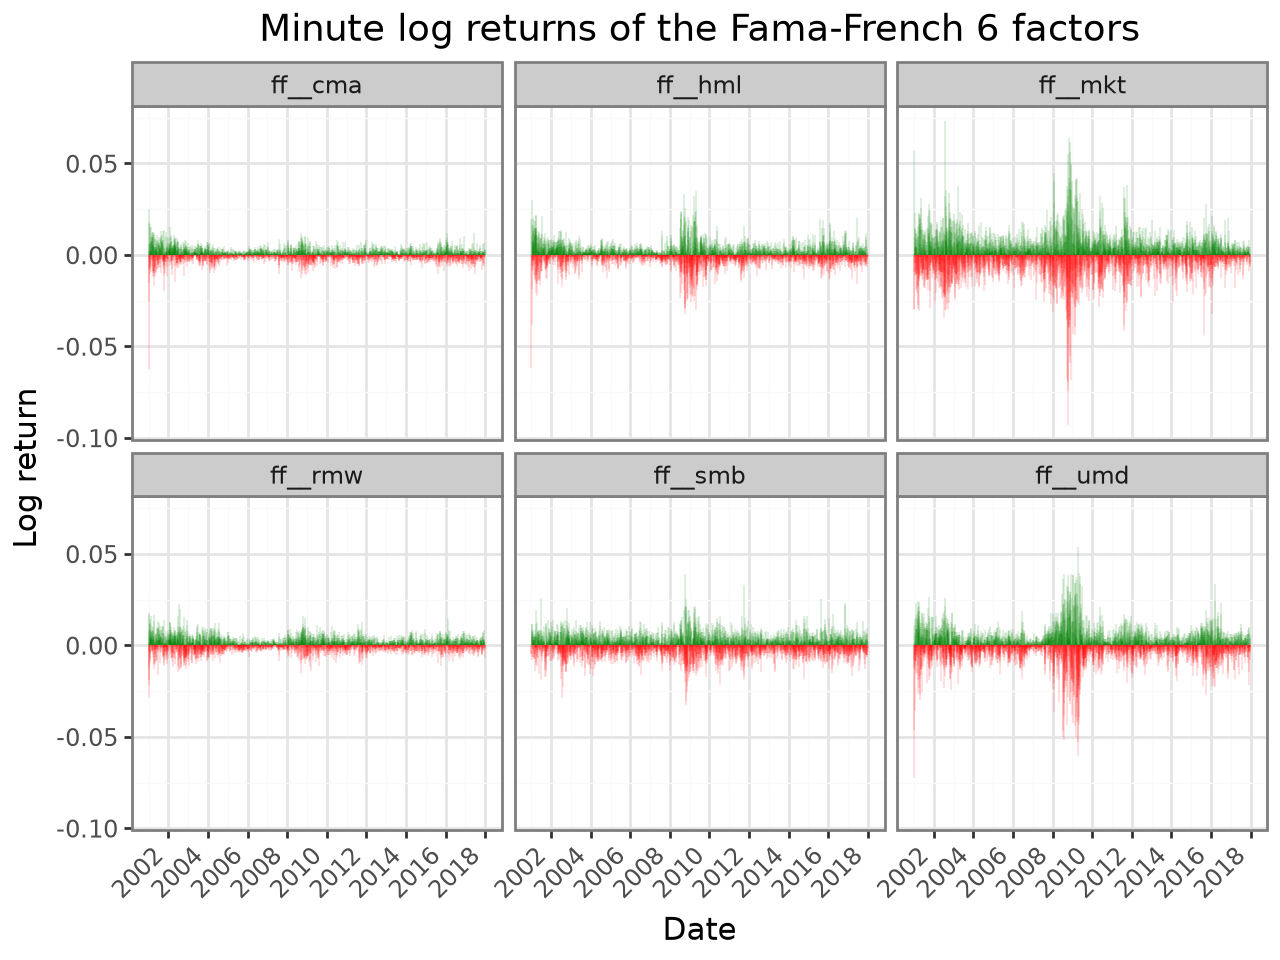

In [ ]:
ut.plot.factors(data_1min, cols_fct)

## Trading days

Here I recall the approach used to define the full trading days considered in this project:

1. The trading days calendar for NYSE is obtained from the `exchange_calendars` and `pandas_market_calendars` python modules, checked against eachother. This is used to validate the raw stock and factor data.
2. Dates where there were less than 390 observations per minute in the factor data or simultaneously across all stocks are deemed as non-full trading days, and removed from the final list of trading days.

At the end, the following non-weekdays are removed from the final list of trading days:

In [47]:
dates_week_all = np.arange(PARS.date_start, PARS.date_end, dtype = 'datetime64[D]')
dates_week_all = dates_week_all[np.is_busday(dates_week_all)]
dates_week_rmv = dates_week_all[~ np.isin(dates_week_all, PARS.trading_days_final)]

print("Weekdays removed:" + ut.format_days_byyear(dates_week_rmv))


- 2001: 01-01, 01-15, 02-19, 04-13, 05-28, 06-08, 07-03, 07-04, 09-03, 09-11, 09-12
    09-13, 09-14, 11-22, 11-23, 12-24, 12-25, 
- 2002: 01-01, 01-21, 02-18, 03-29, 05-27, 07-04, 07-05, 09-02, 09-11, 11-28, 11-29
    12-24, 12-25, 
- 2003: 01-01, 01-20, 02-17, 04-18, 05-26, 07-03, 07-04, 08-15, 09-01, 11-27, 11-28
    12-24, 12-25, 12-26, 
- 2004: 01-01, 01-19, 02-16, 04-09, 05-31, 06-11, 07-05, 09-06, 11-25, 11-26, 12-24, 
- 2005: 01-17, 02-21, 03-25, 05-30, 07-04, 09-05, 11-24, 11-25, 12-23, 12-26, 
- 2006: 01-02, 01-16, 02-20, 04-14, 05-29, 07-03, 07-04, 09-04, 11-23, 11-24, 12-25, 
- 2007: 01-01, 01-02, 01-15, 02-19, 04-06, 05-28, 07-03, 07-04, 09-03, 11-22, 11-23
    12-24, 12-25, 
- 2008: 01-01, 01-21, 02-18, 03-21, 05-26, 07-03, 07-04, 09-01, 11-27, 11-28, 12-24
    12-25, 12-26, 
- 2009: 01-01, 01-19, 02-16, 04-10, 05-25, 07-03, 09-07, 11-26, 11-27, 12-24, 12-25, 
- 2010: 01-01, 01-18, 02-15, 04-02, 05-31, 07-05, 09-06, 11-25, 11-26, 12-24, 12-27, 
- 2011: 01-17, 02-21, 04-2